3. Fig. 2 shows an image of a cricket turf. Listing 1 shows a code snippet that can be used to
click and obtain the four corners. Superimpose the a country flag on the turf

In [1]:
import cv2
import numpy as np

points = []

def mouse_callback ( event , x , y , flags , param ) :
    global points , img_display
    
    if event == cv2 . EVENT_LBUTTONDOWN :
        if len ( points ) < 4:
            points . append (( x , y ) )
            print ( f" Point { len ( points )}: ({x} , {y})")
            cv2 . circle ( img_display , (x , y ) , 5 , (0 , 0 , 255) , -1)
            cv2 . imshow (" Image ", img_display )

        if len ( points ) == 4:
            print ("\ nFour points selected :")
            for i , p in enumerate ( points ) :
                print ( f"P{i +1}: {p}")
            print (" Press any key to exit .")

img = cv2 . imread ("turf.jpg")

if img is None :
    raise FileNotFoundError (" Image not found .")

img_display = img . copy ()

cv2 . namedWindow (" Image ")
cv2 . setMouseCallback (" Image ", mouse_callback )
cv2 . imshow (" Image ", img_display )
cv2 . waitKey (0)
cv2 . destroyAllWindows ()

points = np . array ( points , dtype = np . float32 )

print ("\ nFinal array of selected points :")
print ( points )

 Point 1: (1267 , 637)
 Point 2: (780 , 160)
 Point 3: (627 , 162)
 Point 4: (60 , 638)
\ nFour points selected :
P1: (1267, 637)
P2: (780, 160)
P3: (627, 162)
P4: (60, 638)
 Press any key to exit .
\ nFinal array of selected points :
[[1267.  637.]
 [ 780.  160.]
 [ 627.  162.]
 [  60.  638.]]


Superimposing the image :

In [2]:
# Load the turf.jpg (original turf) image and the flag image
turf_img = cv2.imread("turf.jpg")
flag_img = cv2.imread("sri_lanka.jpg") 

if turf_img is None or flag_img is None:
    raise FileNotFoundError("Could not load turf or flag image.")

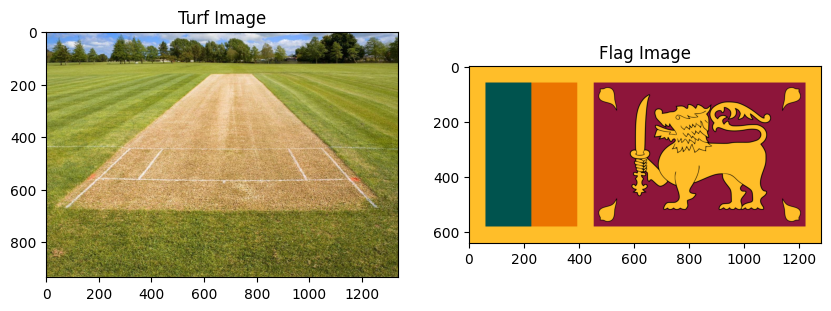

In [3]:
# Display the 2 images using matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Turf Image")
plt.imshow(cv2.cvtColor(turf_img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title("Flag Image")
plt.imshow(cv2.cvtColor(flag_img, cv2.COLOR_BGR2RGB))
plt.show()

In [7]:
# Define the source points (the four corners of the flat flag image)

h_flag, w_flag = flag_img.shape[:2]
pts_src = np.array([
    [0, 0],                 # Top-left
    [w_flag - 1, 0],        # Top-right
    [w_flag - 1, h_flag - 1], # Bottom-right
    [0, h_flag - 1]         # Bottom-left
], dtype=np.float32)

# Define the destination points
pts_dst = points # 'points' is the array generated by clicking the turf in the first part

In [8]:
# Calculate the Homography Matrix
# We map the flat coordinates to the perspective of the turf
h_matrix, status = cv2.findHomography(pts_src, pts_dst)

In [9]:
# Warp the flag image to fit the turf's perspective
# We make the output canvas the exact same size as the turf image
warped_flag = cv2.warpPerspective(flag_img, h_matrix, (turf_img.shape[1], turf_img.shape[0]))

In [10]:
# Masking and Blending (Superimposing)
# Create a mask where the warped flag exists
gray_warped = cv2.cvtColor(warped_flag, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray_warped, 1, 255, cv2.THRESH_BINARY)

In [11]:
# Invert the mask to find the area on the turf where the flag will NOT be
mask_inv = cv2.bitwise_not(mask)

# Black-out the area of the pitch in the original turf image
turf_bg = cv2.bitwise_and(turf_img, turf_img, mask=mask_inv)

# Add the warped flag to the blacked-out area of the turf
final_result = cv2.add(turf_bg, warped_flag)

In [12]:
# Display and save the result
cv2.imshow("Superimposed Flag", final_result)
cv2.imwrite("superimposed_result.jpg", final_result)
cv2.waitKey(0)
cv2.destroyAllWindows()

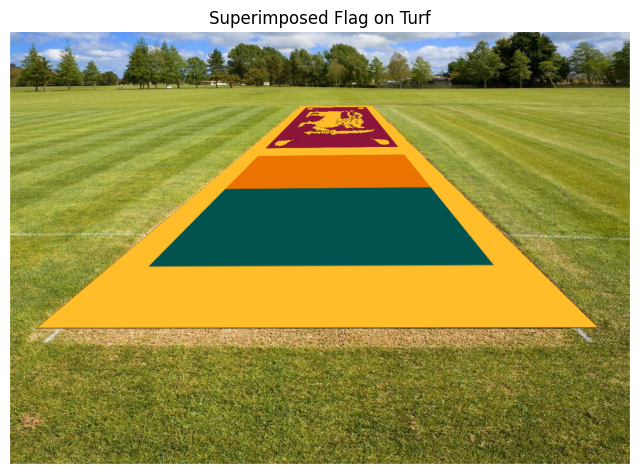

In [13]:
# Display using matplotlib to ensure correct color representation
plt.figure(figsize=(8, 6))
plt.title("Superimposed Flag on Turf")
plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()